# 02 — Búsqueda de hiperparámetros: regresión lineal regularizada

La OLS del notebook 01 no regulariza y sufre la colinealidad de las features
mensuales. Acá buscamos la **regularización** óptima sobre una grilla:

- `penalty`: `none` (OLS) · `l2` (Ridge, encoge coeficientes) · `l1` (Lasso, hace
  selección de features) · `elasticnet` (mezcla L1+L2).
- `alpha`: fuerza de la penalización.
- `l1_ratio`: mezcla L1/L2 (solo aplica a elasticnet).

La selección se hace con **validación cruzada temporal** (`evaluacion.buscar`):
folds de ventana expansiva sobre el train, donde la validación es siempre
*posterior* al entrenamiento de cada fold. **El test (≥2021) no se toca en la
búsqueda** — se usa una sola vez, al final, para reportar las métricas del modelo
elegido.

In [15]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath('..'))          # componente_b/ (datos, evaluacion)
warnings.filterwarnings('ignore')                  # silenciar ConvergenceWarning de sklearn

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')

import datos, evaluacion as ev
from modelos import (LinearRegressor, XGBoostRegressor, NeuralNetRegressor,
                     RandomForestRegressorModel, HistGBMRegressor, StackingRegressorModel)

# Todo el análisis se hace sobre los DOS cultivos. El dataset "principal" usa las
# features agronómicas de ventana crítica (use_agro) y el suavizado del target
# encoding de depto (enc_smooth): la configuración que mejor generaliza.
CULTIVOS = ['soja', 'maiz']
DSS = {c: datos.prepare(c, use_agro=True, enc_smooth=10.0) for c in CULTIVOS}
for c in CULTIVOS:
    d = DSS[c]
    print(f'{c:5s}: {len(d.feature_cols)} features | '
          f'train {d.X_train.shape[0]} filas (≤{datos.TRAIN_END}) | '
          f'test {d.X_test.shape[0]} filas (≥{datos.TEST_START})')


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
soja : 78 features | train 7551 filas (≤2020) | test 942 filas (≥2021)
maiz : 78 features | train 9678 filas (≤2020) | test 1160 filas (≥2021)


## La búsqueda (para soja y maíz)

Grid completo, optimizando RMSE de validación temporal, por cultivo.

In [16]:
grid = {
    'penalty':  ['none', 'ridge', 'lasso', 'elasticnet'],
    'alpha':    [0.1, 1.0, 10.0, 50.0, 100.0],
    'l1_ratio': [0.2, 0.5, 0.8],
}
BEST_LIN, TAB = {}, {}
for c in CULTIVOS:
    TAB[c], BEST_LIN[c] = ev.buscar(LinearRegressor, grid, DSS[c], metric='rmse', n_splits=4)
    print(f'{c}: mejores HP = {BEST_LIN[c]}')
TAB['soja'].head(8)

soja: mejores HP = {'penalty': 'elasticnet', 'alpha': 0.1, 'l1_ratio': 0.2}
maiz: mejores HP = {'penalty': 'ridge', 'alpha': 10.0, 'l1_ratio': 0.2}


,penalty,alpha,l1_ratio,cv_rmse,cv_rmse_std
0,elasticnet,0.100,0.200,640.554,104.733
1,elasticnet,1.000,0.800,640.576,102.013
2,lasso,10.000,0.500,640.817,110.457
3,lasso,10.000,0.200,640.817,110.457
4,lasso,10.000,0.800,640.817,110.457
5,elasticnet,0.100,0.500,641.739,106.609
6,lasso,1.000,0.800,642.226,110.938
7,lasso,1.000,0.500,642.226,110.938


## Modelo final (ambos cultivos)

Reentrenamos con los mejores hiperparámetros sobre **todo** el train y evaluamos en
el test, para cada cultivo.

In [17]:
filas = []
for c in CULTIVOS:
    d = DSS[c]
    m = LinearRegressor(**BEST_LIN[c]).fit(d.X_train, d.y_train)
    filas.append({'cultivo': c, **ev.evaluar('Lineal (final)', m.predict(d.X_test), d)})
    filas.append({'cultivo': c, **ev.evaluar('media x depto', ev.pred_media_depto(d), d)})
pd.DataFrame(filas)[['cultivo', 'modelo', 'mae', 'rmse', 'r2', 'smape']]

,cultivo,modelo,mae,rmse,r2,smape
0,soja,Lineal (final),507.692,660.554,0.257,23.667
1,soja,media x depto,593.307,708.357,0.145,27.169
2,maiz,Lineal (final),"1,519.667","1,969.778",0.036,29.330
3,maiz,media x depto,"1,500.686","1,785.230",0.208,31.662


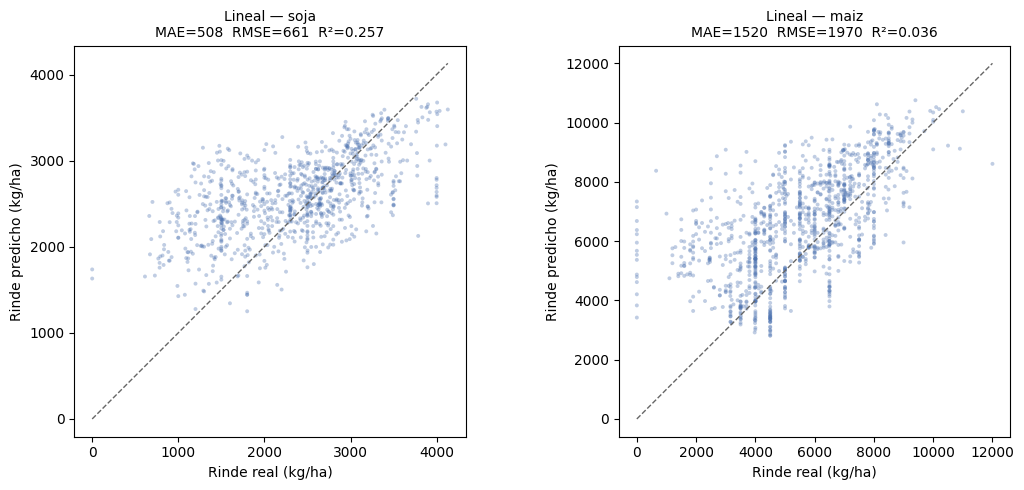

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, c in zip(axes, CULTIVOS):
    d = DSS[c]; m = LinearRegressor(**BEST_LIN[c]).fit(d.X_train, d.y_train)
    ev.plot_pred_vs_real(d.y_test, m.predict(d.X_test), f'Lineal — {c}',
                         color=ev.C_LINEAR, ax=ax)
plt.tight_layout(); plt.show()

## Coeficientes: qué features sobreviven

Con Lasso/ElasticNet muchos coeficientes van a cero — el modelo se queda con las features informativas.

In [19]:
for c in CULTIVOS:
    d = DSS[c]; m = LinearRegressor(**BEST_LIN[c]).fit(d.X_train, d.y_train)
    coef = getattr(m._model, 'coef_', None)
    if coef is None: continue
    s = pd.Series(coef, index=d.feature_cols)
    print(f'{c}: {int((s.abs() < 1e-8).sum())}/{len(s)} coeficientes en cero. Top 6 |coef|:')
    print(s.reindex(s.abs().sort_values(ascending=False).index).head(6).round(1).to_dict())

soja: 1/78 coeficientes en cero. Top 6 |coef|:
{'depto_enc': 244.3000030517578, 'year': 155.8000030517578, 'ndvi_avhrr_ene': 124.4000015258789, 'ndvi_avhrr_feb': 107.5, 'allsky_sfc_sw_dwn_dic': 67.5, 'rh2m_ene': 56.599998474121094}
maiz: 0/78 coeficientes en cero. Top 6 |coef|:
{'depto_enc': 1377.5999755859375, 'year': 1061.5999755859375, 'agro_waterbal_crit': 991.5, 't2m_oct': 938.5, 'oni_oct': -806.5999755859375, 'oni_nov': 789.4000244140625}


## El mejor modelo del Componente A como features

Con la **configuración final ya elegida**, evaluamos en test el dataset (único,
unificado: clima + NDVI + ERA5) contra tres estrategias que reusan el **mejor
detector del Componente A** (el VAE `recon_prob`, que aprendió a representar el
clima "normal"): concatenar su **espacio latente**, hacer la regresión **solo en
el latente**, y agregar la categórica **`es_anomalo`** (su score umbralado).

El latente/score se computan en `latente.py` (y se cachean). *La primera corrida
entrena el VAE, así que tarda unos minutos.*

In [20]:
for c in CULTIVOS:
    print(f'=== {c} ===')
    display(ev.comparar_latente(LinearRegressor, BEST_LIN[c], c, fixed=None,
                                vae_kwargs=dict(score_seeds=(42, 43, 44))))

=== soja ===
[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


,variante,n_feats,mae,rmse,r2,mape,smape
0,+ latente,90,470.809,588.748,0.409,25.014,22.283
1,+ es_anomalo,75,492.124,633.566,0.316,27.837,23.114
2,dataset unificado,74,507.892,661.512,0.255,29.877,23.661
3,solo latente,16,670.415,807.512,-0.111,31.507,30.483


=== maiz ===
[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


,variante,n_feats,mae,rmse,r2,mape,smape
0,+ latente,90,"1,291.930","1,716.499",0.268,32.891,26.877
1,+ es_anomalo,75,"1,357.909","1,794.213",0.200,34.905,27.667
2,dataset unificado,74,"1,525.841","1,977.636",0.029,39.253,29.470
3,solo latente,16,"1,785.723","2,225.869",-0.231,36.884,35.239


## Conclusión

La regularización mejora sobre la OLS cruda y da un modelo lineal estable. El techo
del lineal está en su capacidad de capturar solo relaciones **lineales** entre clima
y rinde; los notebooks 03 (XGBoost) y 04 (red neuronal) prueban si lo no-lineal
paga. En cuanto a features: las de ERA5/NDVI y el latente del VAE se evalúan arriba
(ver la conclusión transversal del nb 05).